## Simulation of Grover's Algorithm in a Ising-Nuclear-Spin Chain System
## Grover's Algorithm

In 1996, Lov Grover introduced a quantum algorithm that performs unstructured database searches quadratically faster than classical methods.

### Problem
Given a set of $N = 2^n$ states represented by binary strings $x_0, \dots, x_{N-1}$, find the element $x_a$ such that $f(x_a) = 1$ while $f(x) = 0$ for all other elements.

### Algorithm Steps

**1. Initialization**
Start with an n-qubit register in the ground state $|0^n\rangle = |00\cdots0\rangle$.

**2. Uniform Superposition**
Apply the Hadamard gate $H$ to each qubit:

$$|s\rangle = \frac{1}{\sqrt{N}}\sum_{x \in \{0,1\}^n} |x\rangle$$

**3. Grover Operator** (repeat $\lfloor \frac{\pi\sqrt{N}}{4} \rfloor$ times)

**a) Quantum Oracle**

$$U_\omega |x\rangle = (-1)^{f(x)}|x\rangle$$

Equivalently defined via the projection operator:

$$P_\omega = I - 2|\omega\rangle\langle\omega|$$

**b) Diffusion Operator**

$$U_{S_{ij}} = \begin{cases} \frac{2}{N} & \text{if } i \neq j \\ -1 + \frac{2}{N} & \text{if } i = j \end{cases}$$

Implemented as $D = H^{\otimes n} R H^{\otimes n}$, where $R = 2|0^n\rangle\langle 0^n| - I_n$:

$$R_{ij} = \begin{cases} 0 & \text{if } i \neq j \\ 1 & \text{if } i = j = 0 \\ -1 & \text{if } i = j \neq 0 \end{cases}$$

**4. Measurement**
Measure the quantum register to obtain the target element with probability close to 1.

**5. Verification**
Verify the result. If incorrect, repeat from step 3.



### Grover's Algorithm for the searching of state $|11\rangle$

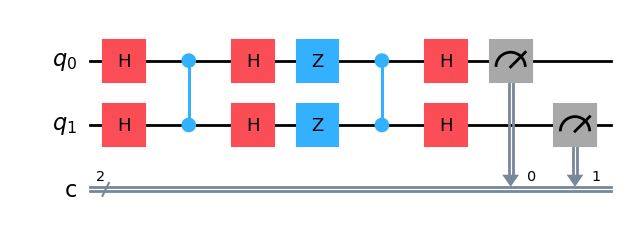

In [1]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

qreg_q = QuantumRegister(2, 'q')
creg_c = ClassicalRegister(2, 'c')
circuit = QuantumCircuit(qreg_q, creg_c)


circuit.h(qreg_q[0]) #Se considera como estado inicial al estado base
circuit.h(qreg_q[1]) #Se considera como estado inicial al estado base

circuit.cz(0,1)

circuit.h(qreg_q[0]) #Se considera como estado inicial al estado base
circuit.h(qreg_q[1]) #Se considera como estado inicial al estado base

circuit.z(qreg_q[0]) #Se considera como estado inicial al estado base
circuit.z(qreg_q[1]) #Se considera como estado inicial al estado base

circuit.cz(0,1)

circuit.h(qreg_q[0]) #Se considera como estado inicial al estado base
circuit.h(qreg_q[1]) #Se considera como estado inicial al estado base


circuit.measure(qreg_q[0],creg_c[0])#Se mide en la base de Z
circuit.measure(qreg_q[1],creg_c[1])#Se mide en la base de Z

circuit.draw("mpl")



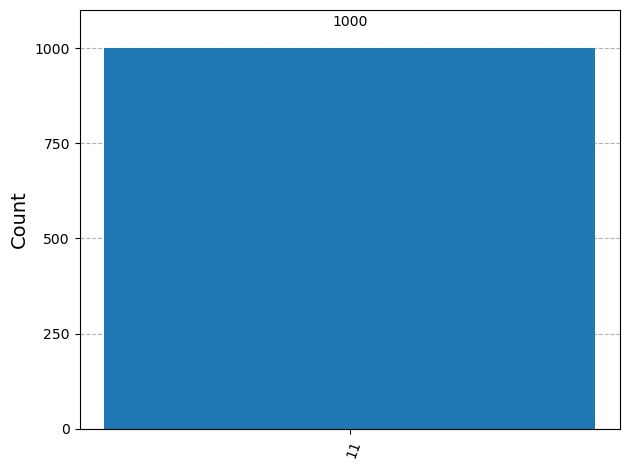

In [2]:
sim = AerSimulator()

compiled = transpile(circuit, sim)

result = sim.run(compiled, shots=1000).result()

counts = result.get_counts()

plot_histogram(counts)

## Physical Model

This work is based on a one-dimensional Ising spin chain of n identical nuclear spins (qubits), interacting with an external magnetic field in the z-direction and radiofrequency (RF) pulses in the x-y plane.

The system Hamiltonian during a pulse of duration τ is:

$$\hat{H} = \hat{H_0} + \hat{W} = -\frac{\hbar}{2}\left(\sum_{k=1}^n \omega_k Z_k - J\sum_{k=1}^{n-1} Z_k Z_{k+1}\right) + \hat{W}$$

where:
- $\omega_k$ is the Larmor frequency of the k-th spin
- $J$ is the coupling constant between neighboring spins
- $Z_k$ is the spin operator in the z-direction

The operator $\hat{W}$ describes the RF pulses, which simulate quantum gates by modifying the frequency and phase of the pulses.

$$\hat{W} = -\frac{\hbar\Omega}{2}\sum_{k=0}^{n-1}\left(I_k^+ e^{i(\omega t+\varphi)} + I_k^- e^{-i(\omega t+\varphi)}\right)$$

where:
- $I_k^+ = |0_k\rangle\langle 1_k|$ — raising operator
- $I_k^- = |1_k\rangle\langle 0_k|$ — lowering operator
- $\Omega$ — Rabi frequency

## Dynamic of quantum computer

To simulate Grover's algorithm, we solve the Schrödinger equation:

$$i\hbar\frac{d|\psi(t)\rangle}{dt} = \hat{H}|\psi(t)\rangle$$

We propose a solution of the form:

$$|\psi\rangle = \sum_{p=0}^{2^n-1} C_p(t)|p\rangle$$

Substituting and using the orthogonality relation $\langle m|p\rangle = \delta_{mp}$, we obtain a system of equations for the coefficients $C_m$:

$$i\hbar\frac{dC_m}{dt} = E_m C_m + \sum_{p=0}^{2^n-1} C_p \langle m|W(t)|p\rangle$$

Since the term $E_m C_m$ generates rapid oscillations, we work in the **interaction picture** to eliminate them:

$$|\psi\rangle = e^{-iH_0 t/\hbar}|\psi_{\text{int}}\rangle$$

With the substitution $C_m = D_m e^{-iE_m t/\hbar}$, we obtain:

$$i\hbar\frac{dD_m}{dt} = \sum_{p=0}^{2^n-1} W_{mp}(t) D_p e^{i\omega_{mp}t}$$

where $\omega_{mp} = (E_m - E_p)/\hbar$ is the transition frequency and the matrix elements of $W$ are:

$$W_{mp}(t) = \begin{cases} -\frac{\hbar\Omega}{2}e^{i(\omega t + \varphi)}, & \text{if } |m\rangle = I_k^+|p\rangle \\ z^*(t), & \text{if } |m\rangle = I_k^-|p\rangle \\ 0, & \text{otherwise} \end{cases}$$

## Resonant Transitions and Error Suppression

When the external field frequency does not match $\omega_{res}$, the transition is non-resonant and may introduce errors. The possible resonant transitions are:

$$\omega_k \pm J, \quad (k = 0 \text{ or } k = N-1)$$
$$\omega_k, \quad \omega_k \pm 2J, \quad (1 \leq k \leq N-2)$$

where "+" corresponds to a nearest neighbor in the ground state and "-" to a nearest neighbor in the excited state.

To suppress errors from non-resonant transitions, we use the **$2\pi k$ method**, which determines the appropriate Rabi frequencies for error-free quantum gate implementation:

$$\Omega^{(k)} = \frac{|\Delta|}{\sqrt{4k^2 - 1}} \quad \text{for a } \pi\text{-pulse}$$

$$\Omega^{(k)} = \frac{|\Delta|}{\sqrt{16k^2 - 1}} \quad \text{for a } \pi/2\text{-pulse}$$

where $\Delta = (E_p - E_m)/\hbar - \omega$ is the detuning frequency between states $|p\rangle$ and $|m\rangle$, and $k$ is an arbitrary integer. The possible values are $\Delta = 2J, 4J$.



## Quantum Gates as Rotations on the Bloch Sphere

A qubit can be represented as a vector on the Bloch sphere, so its evolution can be viewed as a rotation. A rotation by angle $\theta$ around a unit vector $\hat{n} = (n_x, n_y, n_z)$ is:

$$\exp\left(-i\theta\hat{n}\cdot\vec{\sigma}/2\right) = \cos(\theta/2)\mathbb{1} - i\sin(\theta/2)(n_x X + n_y Y + n_z Z)$$

Taking $\hat{n} = (\cos\varphi, \sin\varphi, 0)$, the general rotation matrix is:

$$R(\theta, \varphi) = \begin{pmatrix} \cos(\theta/2) & -ie^{-i\varphi}\sin(\theta/2) \\ -ie^{i\varphi}\sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$$

**Rotation around the x-axis** $R(\theta, 0)$:

$$R_x(\theta) = \begin{pmatrix} \cos(\theta/2) & -i\sin(\theta/2) \\ -i\sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$$

**Rotation around the y-axis** $R(\theta, \pi/2)$:

$$R_y(\theta) = \begin{pmatrix} \cos(\theta/2) & -\sin(\theta/2) \\ \sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$$


## Implementation via RF Pulses

A rotation $R(\theta, \varphi)$ is implemented through an RF pulse of duration $\tau = \theta/\Omega$ and phase $\varphi$:

$$R_k^\mu(\theta, \varphi), \quad \omega = \omega_k + \mu J$$

where $\mu = -2, -1, 0, 1, 2$ is determined by the resonance conditions.

### System of Equations for Two Qubits

Expanding the interaction picture equation for $n=2$ qubits:

$$\begin{cases} \dot{D}_{00} = i\frac{\Omega}{2}\left(D_{01}e^{i((w + E_{00} - E_{01})t + \varphi)} + D_{10}e^{i((w + E_{00} - E_{10})t + \varphi)}\right) \\[6pt] \dot{D}_{01} = i\frac{\Omega}{2}\left(D_{00}e^{-i((w-(E_{01}-E_{00}))t + \varphi)} + D_{11}e^{i((w + E_{01} - E_{11})t + \varphi)}\right) \\[6pt] \dot{D}_{10} = i\frac{\Omega}{2}\left(D_{00}e^{-i((w-(E_{10}-E_{00}))t + \varphi)} + D_{11}e^{i((w + E_{10} - E_{11})t + \varphi)}\right) \\[6pt] \dot{D}_{11} = i\frac{\Omega}{2}\left(D_{01}e^{-i((w-(E_{11}-E_{01}))t + \varphi)} + D_{10}e^{-i((w-(E_{11}-E_{10}))t + \varphi)}\right) \end{cases}$$

This system is solved numerically to simulate the required quantum gates.

## Energy Spectrum and Gate Implementation

### Energy Spectrum (2 qubits)

$$E_{00} = -\frac{\hbar}{2}(\omega_0 + \omega_1 - J) \qquad E_{01} = -\frac{\hbar}{2}(\omega_1 - \omega_0 + J)$$

$$E_{10} = -\frac{\hbar}{2}(\omega_0 - \omega_1 + J) \qquad E_{11} = -\frac{\hbar}{2}(-(\omega_1 + \omega_0) - J)$$

### Hadamard Gate

Since neighboring qubits affect single-qubit gates, we repeat the pulse sequence for all neighbor configurations. The Hadamard gates $H_0$ and $H_1$ are implemented as:

$$-iH_0 = \prod_{\mu=-1,1} R_0^{\mu}(\pi, 0) \prod_{\mu=-1,1} R_0^\mu(\pi/2, \pi/2)$$

$$-iH_1 = \prod_{\mu=-1,1} R_1^{\mu}(\pi, 0) \prod_{\mu=-1,1} R_1^\mu(\pi/2, \pi/2)$$

### CZ Gate

Using the relation $CZ = H_1 \, \text{CNOT} \, H_1$, where CNOT is implemented as:

$$\text{CNOT} = R_1^1(\pi, \pi/2)$$

### $Z_1 Z_2$ Gate

$$Z_1 Z_2 = R_0^1(2\pi, \pi)\, R_1^1(2\pi, \pi)$$

### Global Phase Correction

To correct the global phase $-1$ in $H_0H_1$ and $CZ$:

$$R_0^1(2\pi, \pi)\, R_0^{-1}(2\pi, \pi)$$

In [5]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

J = 20
w0 = 100
w1 = 200
E0 = -0.5 * (w0 + w1 - 0.5 * J)
E1 = -0.5 * (w0 - w1 + 0.5 * J)
E2 = -0.5 * (w1 - w0 + 0.5 * J)
E3 = -0.5 * (-(w1 + w0) - 0.5 * J)

def system(U, t, o, phi, w_k, mu):
    w = w_k + 0.5 * mu * J
    
    x0_real, x0_imag, x1_real, x1_imag, x2_real, x2_imag, x3_real, x3_imag = U
    x0 = x0_real + 1j * x0_imag
    x1 = x1_real + 1j * x1_imag
    x2 = x2_real + 1j * x2_imag
    x3 = x3_real + 1j * x3_imag
    
    dx0dt = 0.5 * o * 1j * (x1 * np.exp(1j * ((w + E0 - E1) * t + phi)) + x2 * np.exp(1j * ((w + E0 - E2) * t + phi)))
    dx1dt = 0.5 * o * 1j * (x0 * np.exp(-1j * ((w - (E1 - E0)) * t + phi)) + x3 * np.exp(1j * ((w + E1 - E3) * t + phi)))
    dx2dt = 0.5 * o * 1j * (x0 * np.exp(-1j * ((w - (E2 - E0)) * t + phi)) + x3 * np.exp(1j * ((w + E2 - E3) * t + phi)))
    dx3dt = 0.5 * o * 1j * (x1 * np.exp(-1j * ((w - (E3 - E1)) * t + phi)) + x2 * np.exp(-1j * ((w - (E3 - E2)) * t + phi)))
    
    return [dx0dt.real, dx0dt.imag, dx1dt.real, dx1dt.imag, dx2dt.real, dx2dt.imag, dx3dt.real, dx3dt.imag]

def rf(omega):
    pulses = [
    # Pulsos para la compuerta Hadamard de dos qubits
    {'o': omega, 'phi': np.pi/2, 'w_k': w0, 'mu': -1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': np.pi/2, 'w_k': w0, 'mu': 1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': 0, 'w_k': w0, 'mu': -1, 'time': np.linspace(0, np.pi/omega, 400)},
    {'o': omega, 'phi': 0, 'w_k': w0, 'mu': 1, 'time': np.linspace(0, np.pi/omega, 400)},

    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': -1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': 0, 'w_k': w1, 'mu': -1, 'time': np.linspace(0, np.pi/omega, 400)},
    {'o': omega, 'phi': 0, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/omega, 400)},

    {'o': omega, 'phi': np.pi, 'w_k': w0, 'mu': -1, 'time': np.linspace(0, 2*np.pi/omega, 400)},
    {'o': omega, 'phi': np.pi, 'w_k': w0, 'mu': 1, 'time': np.linspace(0, 2*np.pi/omega, 400)},

    # Pulsos para la compuerta control z
    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': -1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': 0, 'w_k': w1, 'mu': -1, 'time': np.linspace(0, np.pi/omega, 400)},
    {'o': omega, 'phi': 0, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/omega, 400)},
    
    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/omega, 400)},
   
    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': -1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': 0, 'w_k': w1, 'mu': -1, 'time': np.linspace(0, np.pi/omega, 400)},
    {'o': omega, 'phi': 0, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/omega, 400)},

    {'o': omega, 'phi': np.pi, 'w_k': w0, 'mu': -1, 'time': np.linspace(0, 2*np.pi/omega, 400)},
    {'o': omega, 'phi': np.pi, 'w_k': w0, 'mu': 1, 'time': np.linspace(0, 2*np.pi/omega, 400)},

    # H1H2
    {'o': omega, 'phi': np.pi/2, 'w_k': w0, 'mu': -1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': np.pi/2, 'w_k': w0, 'mu': 1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': 0, 'w_k': w0, 'mu': -1, 'time': np.linspace(0, np.pi/omega, 400)},
    {'o': omega, 'phi': 0, 'w_k': w0, 'mu': 1, 'time': np.linspace(0, np.pi/omega, 400)},

    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': -1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': 0, 'w_k': w1, 'mu': -1, 'time': np.linspace(0, np.pi/omega, 400)},
    {'o': omega, 'phi': 0, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/omega, 400)},

    {'o': omega, 'phi': np.pi, 'w_k': w0, 'mu': -1, 'time': np.linspace(0, 2*np.pi/omega, 400)},
    {'o': omega, 'phi': np.pi, 'w_k': w0, 'mu': 1, 'time': np.linspace(0, 2*np.pi/omega, 400)},

    # Z1Z2
    {'o': omega, 'phi': np.pi, 'w_k': w0, 'mu': 1, 'time': np.linspace(0, 2*np.pi/omega, 400)},
    {'o': omega, 'phi': np.pi, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, 2*np.pi/omega, 400)},

    # Pulsos para la compuerta control z
    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': -1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': 0, 'w_k': w1, 'mu': -1, 'time': np.linspace(0, np.pi/omega, 400)},
    {'o': omega, 'phi': 0, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/omega, 400)},
    
    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/omega, 400)},
   
    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': -1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': 0, 'w_k': w1, 'mu': -1, 'time': np.linspace(0, np.pi/omega, 400)},
    {'o': omega, 'phi': 0, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/omega, 400)},

    {'o': omega, 'phi': np.pi, 'w_k': w0, 'mu': -1, 'time': np.linspace(0, 2*np.pi/omega, 400)},
    {'o': omega, 'phi': np.pi, 'w_k': w0, 'mu': 1, 'time': np.linspace(0, 2*np.pi/omega, 400)},

    # H1H2
    {'o': omega, 'phi': np.pi/2, 'w_k': w0, 'mu': -1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': np.pi/2, 'w_k': w0, 'mu': 1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': 0, 'w_k': w0, 'mu': -1, 'time': np.linspace(0, np.pi/omega, 400)},
    {'o': omega, 'phi': 0, 'w_k': w0, 'mu': 1, 'time': np.linspace(0, np.pi/omega, 400)},

    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': -1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': np.pi/2, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/(2*omega), 400)},
    {'o': omega, 'phi': 0, 'w_k': w1, 'mu': -1, 'time': np.linspace(0, np.pi/omega, 400)},
    {'o': omega, 'phi': 0, 'w_k': w1, 'mu': 1, 'time': np.linspace(0, np.pi/omega, 400)},

    {'o': omega, 'phi': np.pi, 'w_k': w0, 'mu': -1, 'time': np.linspace(0, 2*np.pi/omega, 400)},
    {'o': omega, 'phi': np.pi, 'w_k': w0, 'mu': 1, 'time': np.linspace(0, 2*np.pi/omega, 400)},
]
    
    
        
    return pulses






def simulation(pulses,title):
    # Condiciones iniciales
    x0_real = 1
    x0_imag = 0
    x1_real = 0
    x1_imag = 0
    x2_real = 0
    x2_imag = 0
    x3_real = 0
    x3_imag = 0

    U0 = [x0_real, x0_imag, x1_real, x1_imag, x2_real, x2_imag, x3_real, x3_imag]



    # Arrays to accumulate time and solutions
    total_time = []
    x0_real_total, x0_imag_total = [], []
    x1_real_total, x1_imag_total = [], []
    x2_real_total, x2_imag_total = [], []
    x3_real_total, x3_imag_total = [], []

    # Arrays to accumulate total probabilities
    total_probability = []

    for i, pulse in enumerate(pulses):
        o, phi, w_k, mu, t = pulse['o'], pulse['phi'], pulse['w_k'], pulse['mu'], pulse['time']
    
        sol = odeint(system, U0, t, args=(o, phi, w_k, mu))
    
        # Calculate total probability at each time step and accumulate
        prob = (
        sol[:, 0]**2 + sol[:, 1]**2 +  # |x0|^2
        sol[:, 2]**2 + sol[:, 3]**2 +  # |x1|^2
        sol[:, 4]**2 + sol[:, 5]**2 +  # |x2|^2
        sol[:, 6]**2 + sol[:, 7]**2    # |x3|^2
        )
        total_probability.extend(prob)  # Accumulate directly
    
    # Accumulate time and solution results
        total_time.extend(t + (total_time[-1] if total_time else 0))
        x0_real_total.extend(sol[:, 0])
        x0_imag_total.extend(sol[:, 1])
        x1_real_total.extend(sol[:, 2])
        x1_imag_total.extend(sol[:, 3])
        x2_real_total.extend(sol[:, 4])
        x2_imag_total.extend(sol[:, 5])
        x3_real_total.extend(sol[:, 6])
        x3_imag_total.extend(sol[:, 7])
    
    # Update initial conditions
        U0 = sol[-1]

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Time evolution
    ax1.plot(total_time, x0_real_total, label=r'Re$(D_{00})$')
    ax1.plot(total_time, x1_real_total, label=r'Re$(D_{01})$')
    ax1.plot(total_time, x2_real_total, label=r'Re$(D_{10})$')
    ax1.plot(total_time, x3_real_total, label=r'Re$(D_{11})$', color='red', linewidth=3)
    ax1.plot(total_time, total_probability, label='Total probability', color='black', linestyle='--', linewidth=2)

    ax1.set_xlabel(r"$t = \theta/\Omega$", fontsize=14)
    ax1.set_ylabel('D(t)', fontsize=14)
    ax1.set_title(title, fontsize=14)
    ax1.legend()
    ax1.grid(True)

    # Plot 2: Histogram of final results
    # Calculate final probabilities (squared moduli)
    prob_final_00 = x0_real_total[-1]**2 + x0_imag_total[-1]**2  # |x0|^2
    prob_final_01 = x1_real_total[-1]**2 + x1_imag_total[-1]**2  # |x1|^2
    prob_final_10 = x2_real_total[-1]**2 + x2_imag_total[-1]**2  # |x2|^2
    prob_final_11 = x3_real_total[-1]**2 + x3_imag_total[-1]**2  # |x3|^2

    # Labels and probabilities for the histogram
    states = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
    probabilities = [prob_final_00, prob_final_01, prob_final_10, prob_final_11]

    # Create the histogram
    bars = ax2.bar(states, probabilities, color=['blue', 'green', 'orange', 'red'], alpha=0.7, edgecolor='black')
    ax2.set_ylabel('Probability', fontsize=14)
    ax2.set_xlabel('Quantum states', fontsize=14)
    ax2.set_title('Final probabilities after the last pulse', fontsize=14)
    ax2.set_ylim(0, max(probabilities) * 1.1)
    ax2.grid(True, alpha=0.3)

    # Add values above the bars
    for bar, prob in zip(bars, probabilities):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{prob:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Final values from the last pulse
    print("Final values from the last pulse:")
    print(f"x0_real = {x0_real_total[-1]:.6f}, x0_imag = {x0_imag_total[-1]:.6f}")
    print(f"x1_real = {x1_real_total[-1]:.6f}, x1_imag = {x1_imag_total[-1]:.6f}")
    print(f"x2_real = {x2_real_total[-1]:.6f}, x2_imag = {x2_imag_total[-1]:.6f}")
    print(f"x3_real = {x3_real_total[-1]:.6f}, x3_imag = {x3_imag_total[-1]:.6f}")

    print("\nFinal probabilities:")
    print(f"P(|00⟩) = {prob_final_00:.6f}")
    print(f"P(|01⟩) = {prob_final_01:.6f}")
    print(f"P(|10⟩) = {prob_final_10:.6f}")
    print(f"P(|11⟩) = {prob_final_11:.6f}")
    print(f"Total sum = {sum(probabilities):.6f}")

    # Most probable state
    most_probable_state = states[np.argmax(probabilities)]
    max_probability = max(probabilities)
    print(f"\nMost probable state: {most_probable_state} with probability {max_probability:.6f}")

## Simulation of Hadamard gate for two qubits

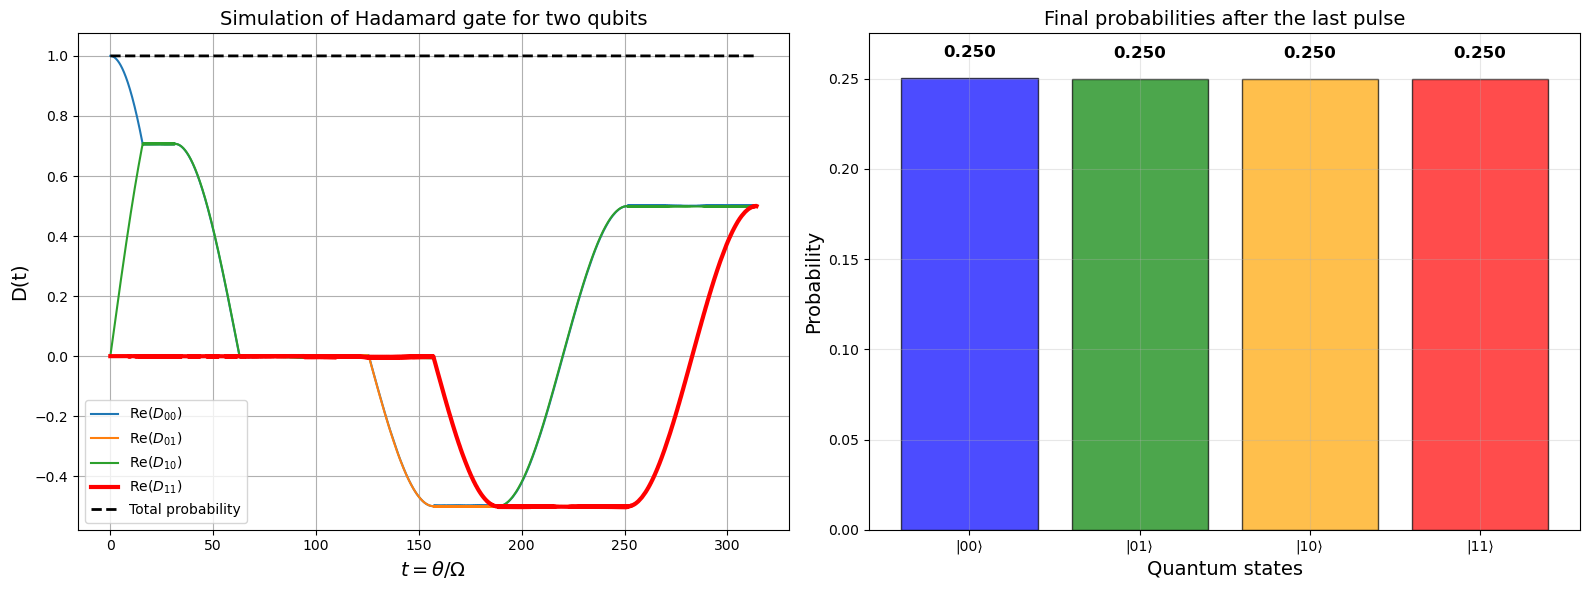

Final values from the last pulse:
x0_real = 0.500170, x0_imag = -0.004155
x1_real = 0.499754, x1_imag = 0.002222
x2_real = 0.500084, x2_imag = 0.007757
x3_real = 0.499908, x3_imag = 0.000775

Final probabilities:
P(|00⟩) = 0.250188
P(|01⟩) = 0.249759
P(|10⟩) = 0.250145
P(|11⟩) = 0.249909
Total sum = 1.000000

Most probable state: |00⟩ with probability 0.250188


In [6]:
pulses1=rf(omega=0.1)
simulation(pulses1[0:10],title="Simulation of Hadamard gate for two qubits")

## Simulation of Control-Z gate

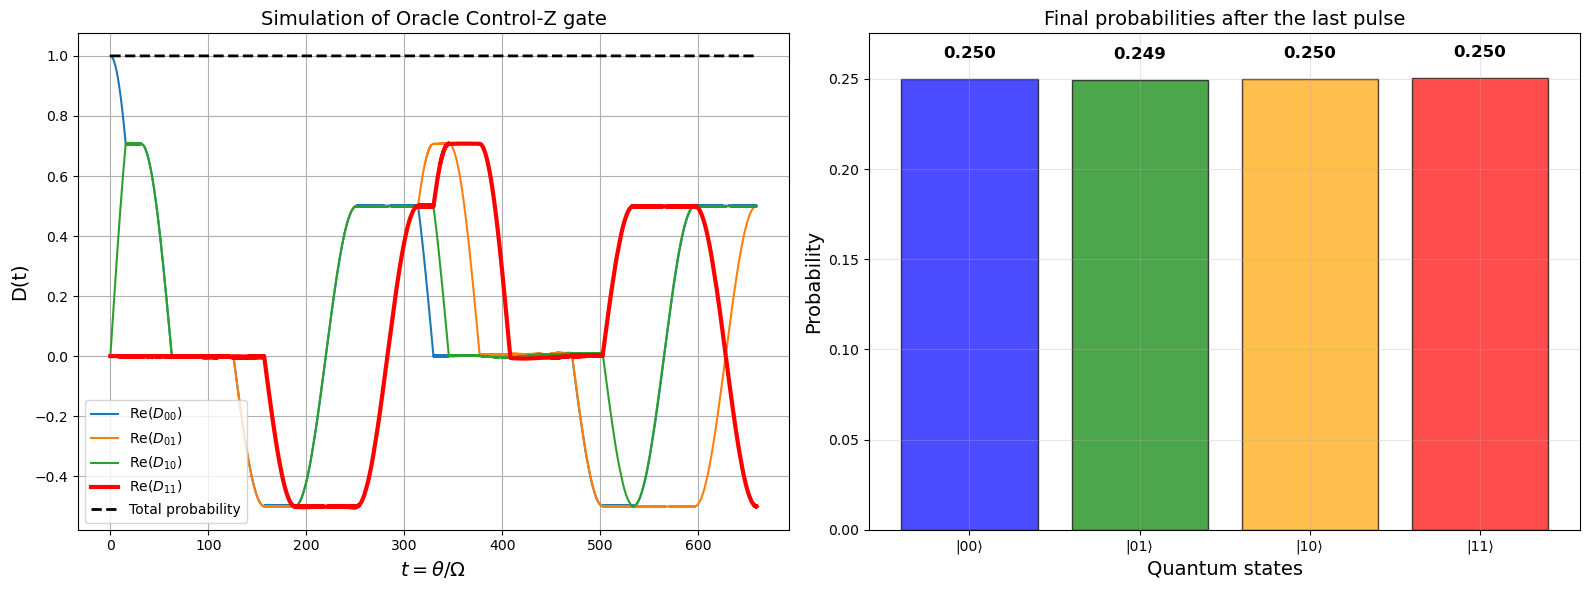

Final values from the last pulse:
x0_real = 0.499985, x0_imag = -0.012882
x1_real = 0.499487, x1_imag = -0.000594
x2_real = 0.500076, x2_imag = 0.003295
x3_real = -0.500251, x3_imag = -0.004741

Final probabilities:
P(|00⟩) = 0.250151
P(|01⟩) = 0.249487
P(|10⟩) = 0.250087
P(|11⟩) = 0.250273
Total sum = 0.999999

Most probable state: |11⟩ with probability 0.250273


In [7]:
pulses2=rf(omega=0.1)[0:21]

simulation(pulses2,title="Simulation of Oracle Control-Z gate")

# Complete simulation of Grover's Algorithm


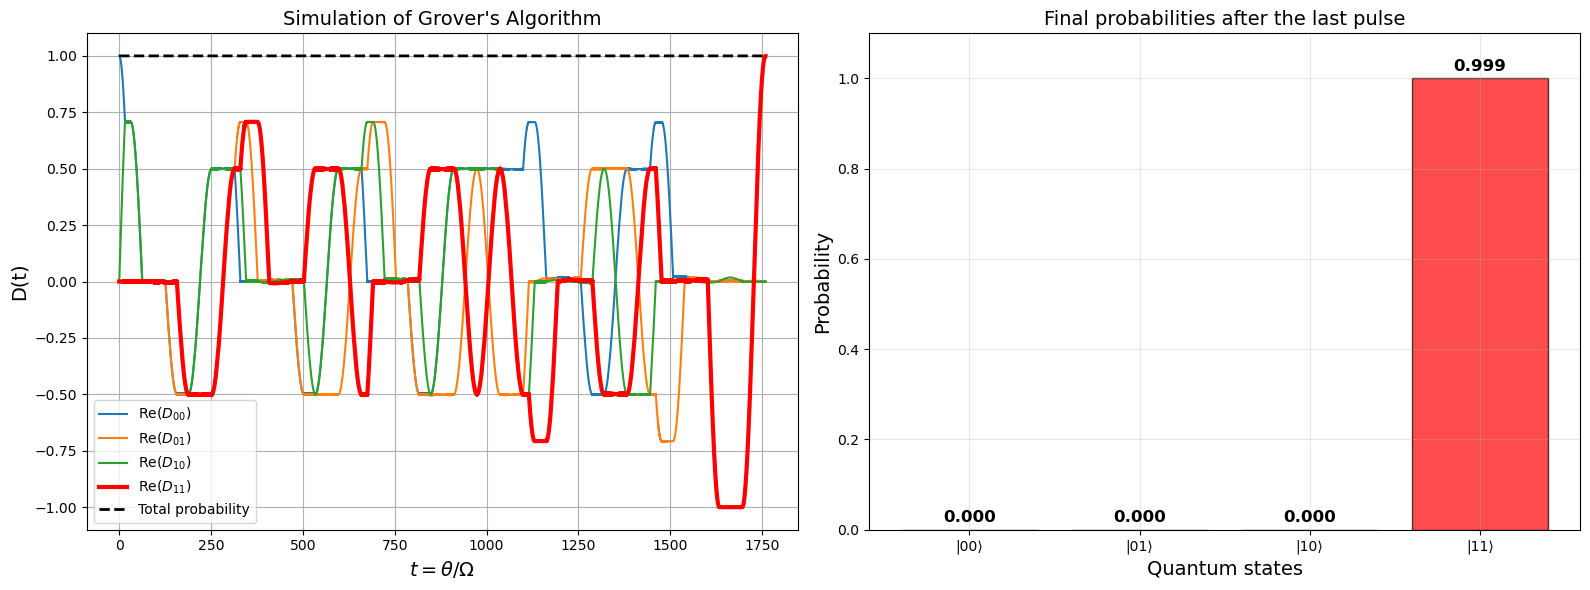

Final values from the last pulse:
x0_real = -0.000602, x0_imag = -0.017911
x1_real = -0.000086, x1_imag = -0.012843
x2_real = -0.000629, x2_imag = -0.005412
x3_real = 0.999729, x3_imag = -0.004929

Final probabilities:
P(|00⟩) = 0.000321
P(|01⟩) = 0.000165
P(|10⟩) = 0.000030
P(|11⟩) = 0.999482
Total sum = 0.999997

Most probable state: |11⟩ with probability 0.999482


In [8]:
simulation(rf(0.1),title="Simulation of Grover's Algorithm")

# Fidelity as function of Rabi's frecuency

## Fidelity Analysis

A general way to determine the impact of non-resonant transitions on the algorithm is through **fidelity**, which measures the similarity between two quantum states. We compare the system evolution under non-resonant transitions against the evolution under resonant transitions only:

$$F = |\langle\psi_{\text{Nores}}|\psi_{\text{res}}\rangle|$$

A fidelity of $F = 1$ indicates identical states, while $F = 0$ indicates orthogonal states. Values close to 1 confirm that non-resonant transitions have negligible impact on the algorithm's performance.

Reference final state: |ψ_ref⟩
  |00⟩: 0.0010
  |01⟩: 0.0009
  |10⟩: 0.0034
  |11⟩: 1.0000


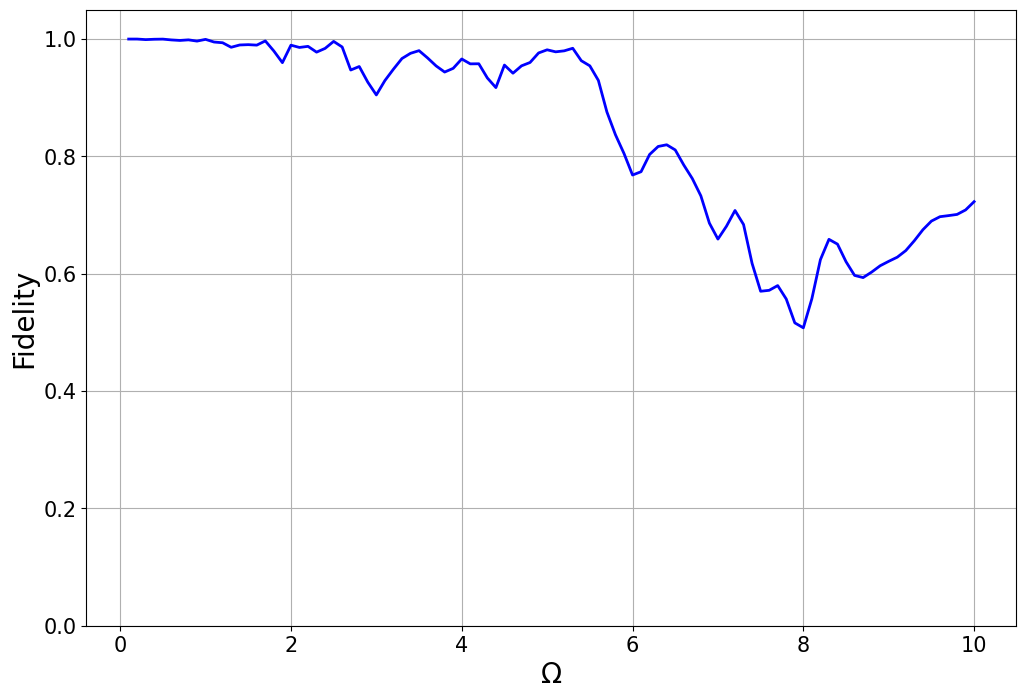

In [9]:
def simulate_full_sequence(omega):
    """Simulates the complete pulse sequence and returns the final state"""
    U0 = [0.5, 0, -0.5, 0, -0.5, 0, 0.5, 0]  # Initial conditions
    pulses = rf(omega)[0:10]
    
    for pulse in pulses:
        o, phi, w_k, mu, t = pulse['o'], pulse['phi'], pulse['w_k'], pulse['mu'], pulse['time']
        sol = odeint(system, U0, t, args=(o, phi, w_k, mu))
        U0 = sol[-1]
    
    return U0

# 1. Simulate the complete sequence with omega=0.1 (reference)
U_final_ref = simulate_full_sequence(0.1)

# Reference state (complex vector)
psi_ref = np.array([
    U_final_ref[0] + 1j*U_final_ref[1],
    U_final_ref[2] + 1j*U_final_ref[3],
    U_final_ref[4] + 1j*U_final_ref[5],
    U_final_ref[6] + 1j*U_final_ref[7]
])

print(f"Reference final state: |ψ_ref⟩")
print(f"  |00⟩: {np.abs(psi_ref[0]):.4f}")
print(f"  |01⟩: {np.abs(psi_ref[1]):.4f}")
print(f"  |10⟩: {np.abs(psi_ref[2]):.4f}")
print(f"  |11⟩: {np.abs(psi_ref[3]):.4f}")

# 2. Sweep of Ω values
omega_values = np.linspace(0.1, 10, 100)
fidelities = []

for omega_val in omega_values:
    U_final_test = simulate_full_sequence(omega_val)
    
    psi_test = np.array([
        U_final_test[0] + 1j*U_final_test[1],
        U_final_test[2] + 1j*U_final_test[3],
        U_final_test[4] + 1j*U_final_test[5],
        U_final_test[6] + 1j*U_final_test[7]
    ])
    
    # Fidelity: F = |<psi_ref|psi_test>|^2
    fidelity = np.abs(np.vdot(psi_ref, psi_test))
    fidelities.append(fidelity)

# 3. Plot results
plt.figure(figsize=(12, 8))
plt.plot(omega_values, fidelities, 'b-', linewidth=2, label='F')
plt.xlabel('Ω', fontsize=20)
plt.ylabel('Fidelity', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True)
plt.ylim([0, 1.05])
plt.show()

## Decoherence Models — Lindblad Master Equation

To model the non-ideal case where environmental effects are considered, we use the **Lindblad master equation** to describe the evolution of the density matrix:

$$\frac{d\rho}{dt} = -\frac{i}{\hbar}[H, \rho] + \mathcal{D}(\rho) = -\frac{i}{\hbar}[H, \rho] + \sum_k \gamma_k\left(L_k \rho L_k^\dagger - \frac{1}{2}\{L_k^\dagger L_k, \rho\}\right)$$

The first term represents the unitary (Hamiltonian) evolution, while the second describes the non-unitary interaction with the environment via the Lindblad operators $L_k$.

Three decoherence models are considered:

---

### Case A — Independent Damping

Describes energy loss from the system to the environment, where an excited spin spontaneously emits a photon and decays to the ground state, destroying superposition:

$$\mathcal{D}^{(A)}(\rho) = \sum_k \gamma_k\left(I^+_k \rho I_k^- - \frac{1}{2}\{I_k^- I_k^+, \rho\}\right)$$

---

### Case B — Pure Dephasing

Describes the gradual loss of off-diagonal elements of the density matrix due to changes in relative phases, while diagonal elements remain unchanged. This is observed in semiconductor quantum dots due to lattice vibrations:

$$\mathcal{D}^{(B)}(\rho) = \sum_k \gamma_k\left(2Z_k \rho Z_k - \{Z_k Z_k, \rho\}\right)$$

---



#### In this work we considerate $\gamma_0=\gamma_1=\gamma$

In [29]:
# Función del sistema con pulsos variables
J = 20
w0 = 100
w1 = 200
E00 = -0.5 * (w0 + w1 - 0.5 * J)
E01 = -0.5 * (w0 - w1 + 0.5 * J)
E10 = -0.5 * (w1 - w0 + 0.5 * J)
E11 = -0.5 * (-(w1 + w0) - 0.5 * J)
pulses=rf(0.1)

def independent(U, t, o, phi, w_k, mu,g0,g1):
    w = w_k + 0.5 * mu * J
    z=-0.5*o*np.exp(1j*(w*t+phi))
    s=-0.5*o*np.exp(-1j*(w*t+phi))
   

    
   
    x00_real, x00_imag, x01_real, x01_imag, x02_real, x02_imag, x03_real, x03_imag, \
    x10_real, x10_imag, x11_real, x11_imag, x12_real, x12_imag, x13_real, x13_imag, \
    x20_real, x20_imag, x21_real, x21_imag, x22_real, x22_imag, x23_real, x23_imag, \
    x30_real, x30_imag, x31_real, x31_imag, x32_real, x32_imag, x33_real, x33_imag = U


    x00 = x00_real + 1j * x00_imag
    x01 = x01_real + 1j * x01_imag
    x02 = x02_real + 1j * x02_imag
    x03 = x03_real + 1j * x03_imag
    x10 = x10_real + 1j * x10_imag
    x11 = x11_real + 1j * x11_imag
    x12 = x12_real + 1j * x12_imag
    x13 = x13_real + 1j * x13_imag
    x20 = x20_real + 1j * x20_imag
    x21 = x21_real + 1j * x21_imag
    x22 = x22_real + 1j * x22_imag
    x23 = x23_real + 1j * x23_imag
    x30 = x30_real + 1j * x30_imag
    x31 = x31_real + 1j * x31_imag
    x32 = x32_real + 1j * x32_imag
    x33 = x33_real + 1j * x33_imag

    dx00dt = -1j*(z*(x20+x10)-s*(x02+x01))+g0*x22+g1*x11
    dx01dt = -1j*(z*(x21+x11-x00)-s*x03-(E01-E00)*x01)+g0*x23-g1*x01/2
    dx02dt = -1j*(z*(x22+x12-x00)-s*x03-(E10-E00)*x02)+g1*x13-g0*x12/2
    dx03dt = -1j*(z*(x23+x13-x02-x01)-(E11-E00)*x03)-(g0+g1)*x03/2
    dx10dt = -1j*(z*x30+s*(-x12-x11+x00)+(E01-E00)*x10)+g0*x32-g1*x10/2
    dx11dt = -1j*(z*(x31-x10)+s*(x01-x13))+g0*x33-g1*x11
    dx12dt = -1j*(z*(x32-x10)+s*(x02-x13)-(E10-E01)*x12)-(g0+g1)*x12/2
    dx13dt = -1j*(z*(x33-x12-x11)+s*x03-(E11-E01)*x13)-(g0/2*+g1)*x13
    dx20dt = -1j*(z*x30+s*(-x22-x21+x00)+(E10-E00)*x20)-g0*x20/2+g1*x31
    dx21dt = -1j*(z*(x31-x20)+s*(x01-x23)+(E10-E01)*x21)-(g0+g1)*x21/2
    dx22dt = -1j*(z*(x32-x20)+s*(x02-x23))-g0*x22+g1*x33
    dx23dt = -1j*(z*(x33-x22-x21)+s*x03-(E11-E10)*x23)-(g0+g1/2)*x23
    dx30dt = -1j*(s*(x20+x10-x32-x31)+(E11-E00)*x30)-(g0+g1)*x30/2
    dx31dt = -1j*(-z*x30+s*(x11+x21-x33)+(E11-E01)*x31)-(g0/2+g1)*x31
    dx32dt = -1j*(-z*x30+s*(-x33+x22+x12)+(E11-E10)*x32)-(g0+g1/2)*x32
    dx33dt = -1j*(z*(-x32-x31)+s*(x23+x13))-(g0+g1)*x33
    
   
    return [
    dx00dt.real, dx00dt.imag,dx01dt.real, dx01dt.imag,dx02dt.real, dx02dt.imag,dx03dt.real, dx03dt.imag,dx10dt.real, dx10dt.imag,dx11dt.real, 
    dx11dt.imag, dx12dt.real, dx12dt.imag, dx13dt.real, dx13dt.imag, dx20dt.real, dx20dt.imag, dx21dt.real, dx21dt.imag, dx22dt.real, dx22dt.imag,
    dx23dt.real, dx23dt.imag,dx30dt.real, dx30dt.imag,dx31dt.real, dx31dt.imag,dx32dt.real, dx32dt.imag,dx33dt.real, dx33dt.imag
    ]

def dephasing (U, t, o, phi, w_k, mu,g0,g1):
    w = w_k + 0.5 * mu * J
    z=-0.5*o*np.exp(1j*(w*t+phi))
    s=-0.5*o*np.exp(-1j*(w*t+phi))

    x00_real, x00_imag, x01_real, x01_imag, x02_real, x02_imag, x03_real, x03_imag, \
    x10_real, x10_imag, x11_real, x11_imag, x12_real, x12_imag, x13_real, x13_imag, \
    x20_real, x20_imag, x21_real, x21_imag, x22_real, x22_imag, x23_real, x23_imag, \
    x30_real, x30_imag, x31_real, x31_imag, x32_real, x32_imag, x33_real, x33_imag = U


    x00 = x00_real + 1j * x00_imag
    x01 = x01_real + 1j * x01_imag
    x02 = x02_real + 1j * x02_imag
    x03 = x03_real + 1j * x03_imag
    x10 = x10_real + 1j * x10_imag
    x11 = x11_real + 1j * x11_imag
    x12 = x12_real + 1j * x12_imag
    x13 = x13_real + 1j * x13_imag
    x20 = x20_real + 1j * x20_imag
    x21 = x21_real + 1j * x21_imag
    x22 = x22_real + 1j * x22_imag
    x23 = x23_real + 1j * x23_imag
    x30 = x30_real + 1j * x30_imag
    x31 = x31_real + 1j * x31_imag
    x32 = x32_real + 1j * x32_imag
    x33 = x33_real + 1j * x33_imag
    

    
    dx00dt = -1j*(z*(x20+x10)-s*(x02+x01))
    dx01dt = -1j*(z*(x21+x11-x00)-s*x03-(E01-E00)*x01)-g1*x01
    dx02dt = -1j*(z*(x22+x12-x00)-s*x03-(E10-E00)*x02)-g0*x02
    dx03dt = -1j*(z*(x23+x13-x02-x01)-(E11-E00)*x03)-(g0+g1)*x03
    dx10dt = -1j*(z*x30+s*(-x12-x11+x00)+(E01-E00)*x10)-g1*x10
    dx11dt = -1j*(z*(x31-x10)+s*(x01-x13))
    dx12dt = -1j*(z*(x32-x10)+s*(x02-x13)-(E10-E01)*x12)-(g0+g1)*x12
    dx13dt = -1j*(z*(x33-x12-x11)+s*x03-(E11-E01)*x13)-g0*x13
    dx20dt = -1j*(z*x30+s*(-x22-x21+x00)+(E10-E00)*x20)-g0*x20
    dx21dt = -1j*(z*(x31-x20)+s*(x01-x23)+(E10-E01)*x21)-(g0+g1)*x21
    dx22dt = -1j*(z*(x32-x20)+s*(x02-x23))
    dx23dt = -1j*(z*(x33-x22-x21)+s*x03-(E11-E10)*x23)-g1*x23
    
    dx30dt = -1j*(s*(x20+x10-x32-x31)+(E11-E00)*x30)-(g0+g1)*x30
    dx31dt = -1j*(-z*x30+s*(x11+x21-x33)+(E11-E01)*x31)-g0*x31
    dx32dt = -1j*(-z*x30+s*(-x33+x22+x12)+(E11-E10)*x32)-g1*x32
    dx33dt = -1j*(z*(-x32-x31)+s*(x23+x13))
    return [
    dx00dt.real, dx00dt.imag,dx01dt.real, dx01dt.imag,dx02dt.real, dx02dt.imag,dx03dt.real, dx03dt.imag,dx10dt.real, dx10dt.imag,dx11dt.real, 
    dx11dt.imag, dx12dt.real, dx12dt.imag, dx13dt.real, dx13dt.imag, dx20dt.real, dx20dt.imag, dx21dt.real, dx21dt.imag, dx22dt.real, dx22dt.imag,
    dx23dt.real, dx23dt.imag,dx30dt.real, dx30dt.imag,dx31dt.real, dx31dt.imag,dx32dt.real, dx32dt.imag,dx33dt.real, dx33dt.imag
    ]

U0 = [1 if i == 0 else 0 for i in range(32)]



def simulation2(pulses, U0, system,g0,g1,title):
    total_time = []
    probability = []

    components = {
        f'x{i}{j}_{part}': []
        for i in range(4)
        for j in range(4)
        for part in ('real', 'imag')
    }

    for pulse in pulses:
        o, phi, w_k, mu, t = pulse['o'], pulse['phi'], pulse['w_k'], pulse['mu'], pulse['time']

        sol = odeint(system, U0, t, args=(o, phi, w_k, mu,g0,g1))

        prob = sol[:, 0] + sol[:, 10] + sol[:, 20] + sol[:, 30]
        probability.extend(prob)

        offset = total_time[-1] if total_time else 0
        total_time.extend(t + offset)

        idx = 0
        for i in range(4):
            for j in range(4):
                components[f'x{i}{j}_real'].extend(sol[:, idx])
                components[f'x{i}{j}_imag'].extend(sol[:, idx + 1])
                idx += 2

        U0 = sol[-1]

    # Plot
    x00, x11, x22, x33 = (components[f'x{i}{i}_real'] for i in range(4))
    max_idx = np.argmax(x22)

    plt.figure(figsize=(9, 5))
    plt.plot(total_time, x00, label=r'Re($\rho_{00}$)', linestyle='--')
    plt.plot(total_time, x11, label=r'Re($\rho_{11}$)', linestyle='--')
    plt.plot(total_time, x22, label=r'Re($\rho_{22}$)', linestyle='--')
    plt.plot(total_time, x33, color='red', linewidth=3)
    plt.plot(total_time, probability, color='black', linestyle='--', linewidth=3)

    plt.xlabel(r"$t = \theta/\Omega$", fontsize=15)
    plt.ylabel(r"$\rho_{ii}$", fontsize=15)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.annotate(r'$\rho_{00}$',
                 xy=(total_time[0], x00[0]),
                 xytext=(total_time[0] + 100, x00[0] - 0.25),
                 arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=15)
    plt.annotate(r'$\rho_{22}$',
                 xy=(total_time[max_idx], x22[max_idx]),
                 xytext=(total_time[max_idx] - 310, x22[max_idx] - 0.20),
                 arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=15)
    plt.annotate(r'$\rho_{33}$',
                 xy=(total_time[-1], x33[-1]),
                 xytext=(total_time[-1] - 440, x33[-1] + 0.05),
                 arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=15)
    plt.annotate(r'Tr($\rho$)',
                 xy=(800, 1.0), xytext=(800, 0.75),
                 arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=15)

    plt.grid(True)
    plt.title(title, fontsize=15)
    plt.show()

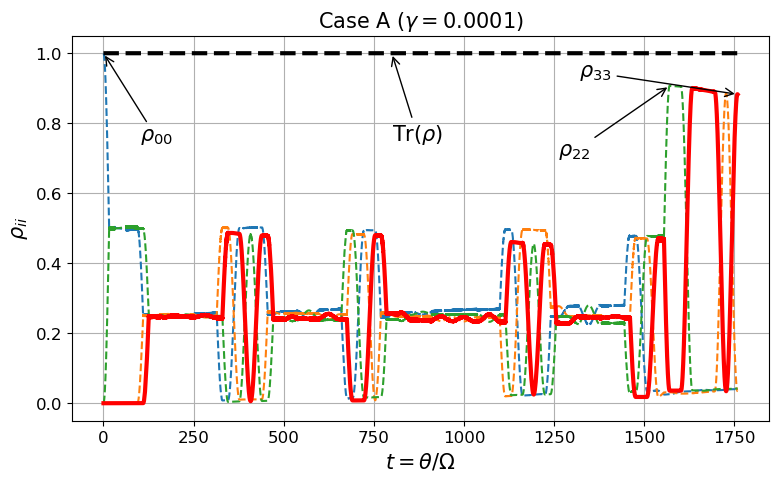

In [15]:
simulation2(pulses, U0, independent, title=r'Case A ($\gamma=0.0001$)',g0=0.0001,g1=0.0001)

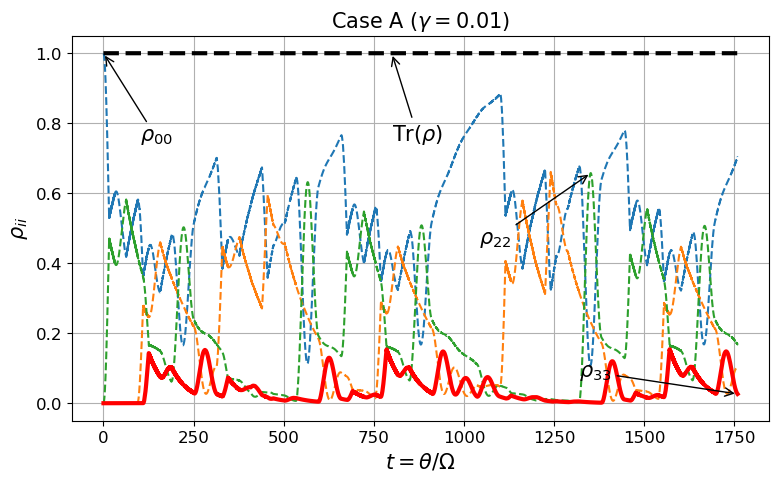

In [16]:
simulation2(pulses, U0, independent, title=r'Case A ($\gamma=0.01$)',g0=0.01,g1=0.01)

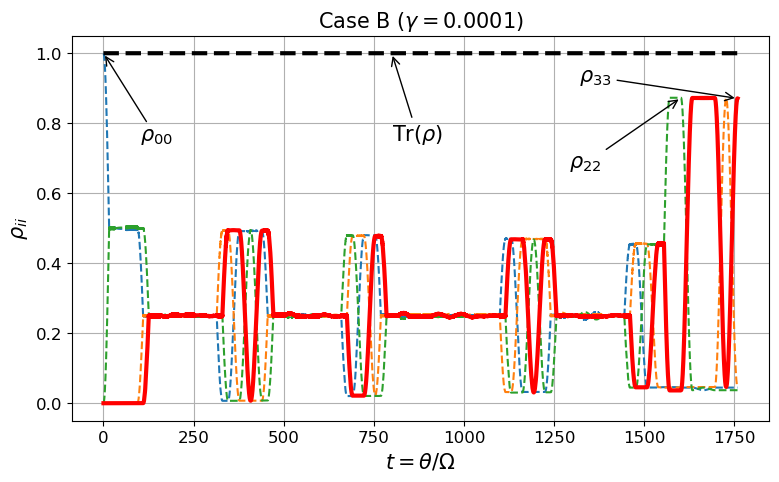

In [17]:
simulation2(pulses, U0, dephasing, title=r'Case B ($\gamma=0.0001$)',g0=0.0001,g1=0.0001)

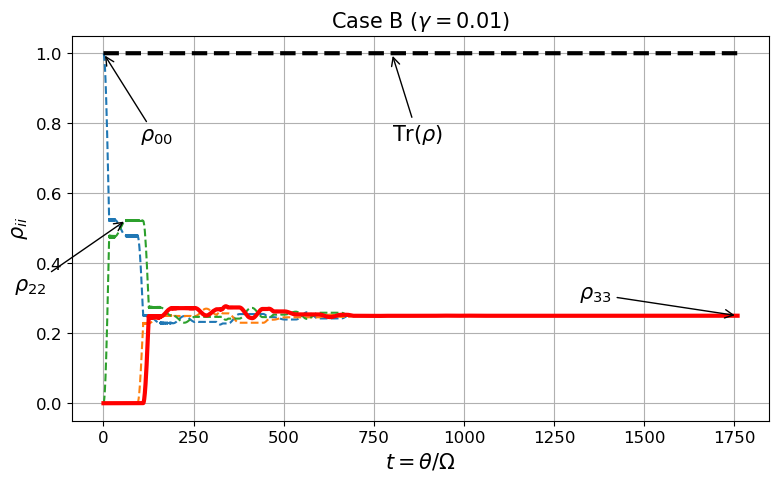

In [18]:
simulation2(pulses, U0, dephasing, title=r'Case B ($\gamma=0.01$)',g0=0.01,g1=0.01)

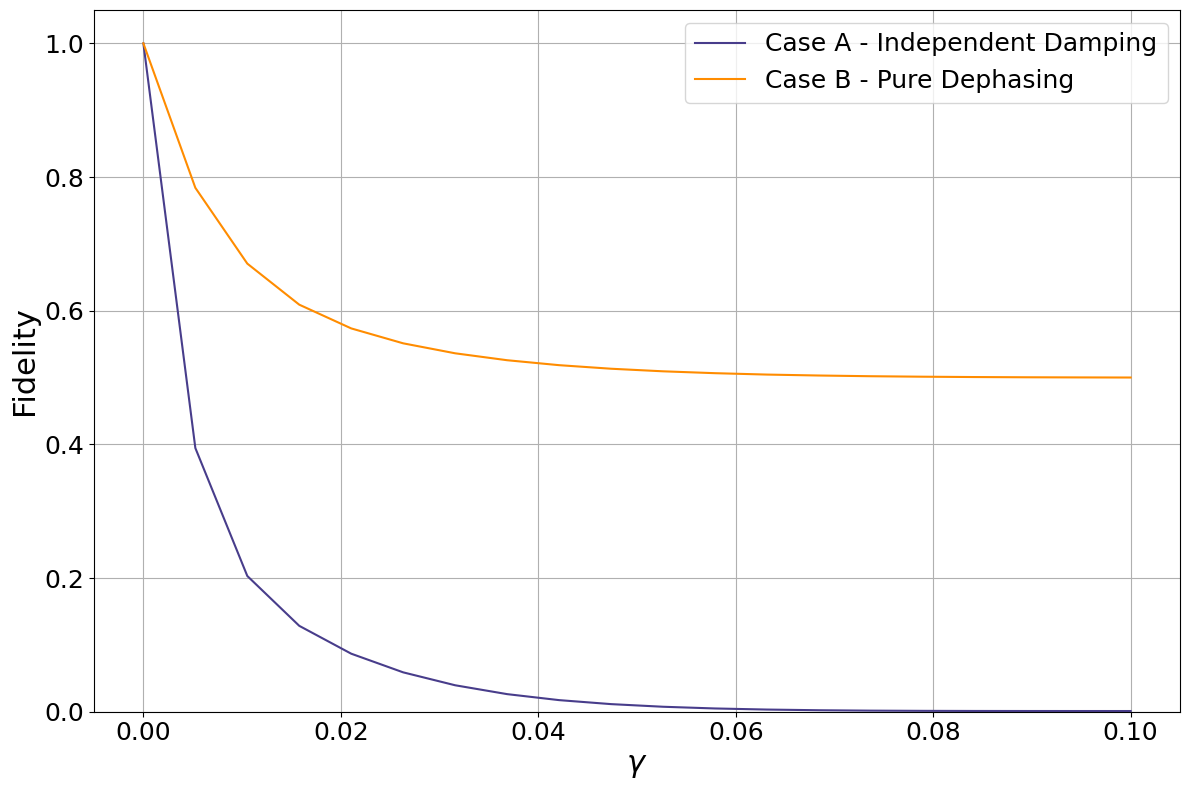

In [35]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# --- System Parameters ---
J = 20
w0 = 100
w1 = 200
E00 = -0.5 * (w0 + w1 - 0.5 * J)
E01 = -0.5 * (w0 - w1 + 0.5 * J)
E10 = -0.5 * (w1 - w0 + 0.5 * J)
E11 = -0.5 * (-(w1 + w0) - 0.5 * J)

# --- Pure State System ---
def system(U, t, o, phi, w_k, mu):
    w = w_k + 0.5 * mu * J
    x0_real, x0_imag, x1_real, x1_imag, x2_real, x2_imag, x3_real, x3_imag = U
    x0 = x0_real + 1j * x0_imag
    x1 = x1_real + 1j * x1_imag
    x2 = x2_real + 1j * x2_imag
    x3 = x3_real + 1j * x3_imag

    dx0dt = 0.5*o*1j*(x1*np.exp(1j*((w+E00-E01)*t+phi)) + x2*np.exp(1j*((w+E00-E10)*t+phi)))
    dx1dt = 0.5*o*1j*(x0*np.exp(-1j*((w-(E01-E00))*t+phi)) + x3*np.exp(1j*((w+E01-E11)*t+phi)))
    dx2dt = 0.5*o*1j*(x0*np.exp(-1j*((w-(E10-E00))*t+phi)) + x3*np.exp(1j*((w+E10-E11)*t+phi)))
    dx3dt = 0.5*o*1j*(x1*np.exp(-1j*((w-(E11-E01))*t+phi)) + x2*np.exp(-1j*((w-(E11-E10))*t+phi)))

    return [dx0dt.real, dx0dt.imag, dx1dt.real, dx1dt.imag,
            dx2dt.real, dx2dt.imag, dx3dt.real, dx3dt.imag]

# --- Case A: Independent Damping ---
def independent(U, t, o, phi, w_k, mu, g_param):
    w = w_k + 0.5 * mu * J
    z = -0.5 * o * np.exp(1j * (w * t + phi))
    s = -0.5 * o * np.exp(-1j * (w * t + phi))
    g = g_param
    g0 = g_param
    g1 = g_param

    y00_real, y00_imag, y01_real, y01_imag, y02_real, y02_imag, y03_real, y03_imag, \
    y10_real, y10_imag, y11_real, y11_imag, y12_real, y12_imag, y13_real, y13_imag, \
    y20_real, y20_imag, y21_real, y21_imag, y22_real, y22_imag, y23_real, y23_imag, \
    y30_real, y30_imag, y31_real, y31_imag, y32_real, y32_imag, y33_real, y33_imag = U

    y00 = y00_real + 1j*y00_imag; y01 = y01_real + 1j*y01_imag
    y02 = y02_real + 1j*y02_imag; y03 = y03_real + 1j*y03_imag
    y10 = y10_real + 1j*y10_imag; y11 = y11_real + 1j*y11_imag
    y12 = y12_real + 1j*y12_imag; y13 = y13_real + 1j*y13_imag
    y20 = y20_real + 1j*y20_imag; y21 = y21_real + 1j*y21_imag
    y22 = y22_real + 1j*y22_imag; y23 = y23_real + 1j*y23_imag
    y30 = y30_real + 1j*y30_imag; y31 = y31_real + 1j*y31_imag
    y32 = y32_real + 1j*y32_imag; y33 = y33_real + 1j*y33_imag

    dy00dt = -1j*(z*(y20+y10)-s*(y02+y01)) + g*y22 + g*y11
    dy01dt = -1j*(z*(y21+y11-y00)-s*y03-(E01-E00)*y01) + g*y23 - g*y01/2
    dy02dt = -1j*(z*(y22+y12-y00)-s*y03-(E10-E00)*y02) + g*y13 - g*y12/2
    dy03dt = -1j*(z*(y23+y13-y02-y01)-(E11-E00)*y03) - (g+g)*y03/2
    dy10dt = -1j*(z*y30+s*(-y12-y11+y00)+(E01-E00)*y10) + g*y32 - g*y10/2
    dy11dt = -1j*(z*(y31-y10)+s*(y01-y13)) + g*y33 - g*y11
    dy12dt = -1j*(z*(y32-y10)+s*(y02-y13)-(E10-E01)*y12) - (g+g)*y12/2
    dy13dt = -1j*(z*(y33-y12-y11)+s*y03-(E11-E01)*y13) - (g/2+g)*y13
    dy20dt = -1j*(z*y30+s*(-y22-y21+y00)+(E10-E00)*y20) - g*y20/2 + g*y31
    dy21dt = -1j*(z*(y31-y20)+s*(y01-y23)+(E10-E01)*y21) - (g+g)*y21/2
    dy22dt = -1j*(z*(y32-y20)+s*(y02-y23)) - g0*y22 + g1*y33
    dy23dt = -1j*(z*(y33-y22-y21)+s*y03-(E11-E10)*y23) - (g+g/2)*y23
    dy30dt = -1j*(s*(y20+y10-y32-y31)+(E11-E00)*y30) - (g+g)*y30/2
    dy31dt = -1j*(-z*y30+s*(y11+y21-y33)+(E11-E01)*y31) - (g/2+g)*y31
    dy32dt = -1j*(-z*y30+s*(-y33+y22+y12)+(E11-E10)*y32) - (g+g/2)*y32
    dy33dt = -1j*(z*(-y32-y31)+s*(y23+y13)) - (g+g)*y33

    return [
        dy00dt.real, dy00dt.imag, dy01dt.real, dy01dt.imag, dy02dt.real, dy02dt.imag, dy03dt.real, dy03dt.imag,
        dy10dt.real, dy10dt.imag, dy11dt.real, dy11dt.imag, dy12dt.real, dy12dt.imag, dy13dt.real, dy13dt.imag,
        dy20dt.real, dy20dt.imag, dy21dt.real, dy21dt.imag, dy22dt.real, dy22dt.imag, dy23dt.real, dy23dt.imag,
        dy30dt.real, dy30dt.imag, dy31dt.real, dy31dt.imag, dy32dt.real, dy32dt.imag, dy33dt.real, dy33dt.imag]

# --- Case B: Pure Dephasing ---
def dephasing(U, t, o, phi, w_k, mu, g_param):
    w = w_k + 0.5 * mu * J
    z = -0.5 * o * np.exp(1j * (w * t + phi))
    s = -0.5 * o * np.exp(-1j * (w * t + phi))
    g = g_param

    y00_real, y00_imag, y01_real, y01_imag, y02_real, y02_imag, y03_real, y03_imag, \
    y10_real, y10_imag, y11_real, y11_imag, y12_real, y12_imag, y13_real, y13_imag, \
    y20_real, y20_imag, y21_real, y21_imag, y22_real, y22_imag, y23_real, y23_imag, \
    y30_real, y30_imag, y31_real, y31_imag, y32_real, y32_imag, y33_real, y33_imag = U

    y00 = y00_real + 1j*y00_imag; y01 = y01_real + 1j*y01_imag
    y02 = y02_real + 1j*y02_imag; y03 = y03_real + 1j*y03_imag
    y10 = y10_real + 1j*y10_imag; y11 = y11_real + 1j*y11_imag
    y12 = y12_real + 1j*y12_imag; y13 = y13_real + 1j*y13_imag
    y20 = y20_real + 1j*y20_imag; y21 = y21_real + 1j*y21_imag
    y22 = y22_real + 1j*y22_imag; y23 = y23_real + 1j*y23_imag
    y30 = y30_real + 1j*y30_imag; y31 = y31_real + 1j*y31_imag
    y32 = y32_real + 1j*y32_imag; y33 = y33_real + 1j*y33_imag

    dy00dt = -1j*(z*(y20+y10)-s*(y02+y01))
    dy01dt = -1j*(z*(y21+y11-y00)-s*y03-(E01-E00)*y01) - g*y01
    dy02dt = -1j*(z*(y22+y12-y00)-s*y03-(E10-E00)*y02) - g*y02
    dy03dt = -1j*(z*(y23+y13-y02-y01)-(E11-E00)*y03) - 2*g*y03
    dy10dt = -1j*(z*y30+s*(-y12-y11+y00)+(E01-E00)*y10) - g*y10
    dy11dt = -1j*(z*(y31-y10)+s*(y01-y13))
    dy12dt = -1j*(z*(y32-y10)+s*(y02-y13)-(E10-E01)*y12) - 2*g*y12
    dy13dt = -1j*(z*(y33-y12-y11)+s*y03-(E11-E01)*y13) - g*y13
    dy20dt = -1j*(z*y30+s*(-y22-y21+y00)+(E10-E00)*y20) - g*y20
    dy21dt = -1j*(z*(y31-y20)+s*(y01-y23)+(E10-E01)*y21) - 2*g*y21
    dy22dt = -1j*(z*(y32-y20)+s*(y02-y23))
    dy23dt = -1j*(z*(y33-y22-y21)+s*y03-(E11-E10)*y23) - g*y23
    dy30dt = -1j*(s*(y20+y10-y32-y31)+(E11-E00)*y30) - 2*g*y30
    dy31dt = -1j*(-z*y30+s*(y11+y21-y33)+(E11-E01)*y31) - g*y31
    dy32dt = -1j*(-z*y30+s*(-y33+y22+y12)+(E11-E10)*y32) - g*y32
    dy33dt = -1j*(z*(-y32-y31)+s*(y23+y13))

    return [
        dy00dt.real, dy00dt.imag, dy01dt.real, dy01dt.imag, dy02dt.real, dy02dt.imag, dy03dt.real, dy03dt.imag,
        dy10dt.real, dy10dt.imag, dy11dt.real, dy11dt.imag, dy12dt.real, dy12dt.imag, dy13dt.real, dy13dt.imag,
        dy20dt.real, dy20dt.imag, dy21dt.real, dy21dt.imag, dy22dt.real, dy22dt.imag, dy23dt.real, dy23dt.imag,
        dy30dt.real, dy30dt.imag, dy31dt.real, dy31dt.imag, dy32dt.real, dy32dt.imag, dy33dt.real, dy33dt.imag]

# --- Initial Conditions ---
U0 = [0.5, 0, -0.5, 0, -0.5, 0, 0.5, 0]
U0_system_1 = [
    0.25, 0, -0.25, 0, -0.25, 0,  0.25, 0,
   -0.25, 0,  0.25, 0,  0.25, 0, -0.25, 0,
   -0.25, 0,  0.25, 0,  0.25, 0, -0.25, 0,
    0.25, 0, -0.25, 0, -0.25, 0,  0.25, 0
]

pulses = [
    {'o': 0.1, 'phi': np.pi/2, 'w_k': w0, 'mu': -1, 'tiempo': np.linspace(0, np.pi/(2*0.1), 400)},
    {'o': 0.1, 'phi': np.pi/2, 'w_k': w0, 'mu':  1, 'tiempo': np.linspace(0, np.pi/(2*0.1), 400)},
    {'o': 0.1, 'phi': np.pi,   'w_k': w0, 'mu': -1, 'tiempo': np.linspace(0, np.pi/0.1,     400)},
    {'o': 0.1, 'phi': np.pi,   'w_k': w0, 'mu':  1, 'tiempo': np.linspace(0, np.pi/0.1,     400)},
    {'o': 0.1, 'phi': np.pi/2, 'w_k': w1, 'mu': -1, 'tiempo': np.linspace(0, np.pi/(2*0.1), 400)},
    {'o': 0.1, 'phi': np.pi/2, 'w_k': w1, 'mu':  1, 'tiempo': np.linspace(0, np.pi/(2*0.1), 400)},
    {'o': 0.1, 'phi': np.pi,   'w_k': w1, 'mu': -1, 'tiempo': np.linspace(0, np.pi/0.1,     400)},
    {'o': 0.1, 'phi': np.pi,   'w_k': w1, 'mu':  1, 'tiempo': np.linspace(0, np.pi/0.1,     400)},
    {'o': 0.1, 'phi': 0,       'w_k': w0, 'mu': -1, 'tiempo': np.linspace(0, 2*np.pi/0.1,   400)},
    {'o': 0.1, 'phi': 0,       'w_k': w0, 'mu':  1, 'tiempo': np.linspace(0, 2*np.pi/0.1,   400)},
]

# --- Auxiliary Functions ---
def calculate_fidelity(pure_state, density_matrix):
    psi = np.array(pure_state).reshape(-1, 1)
    return np.sqrt(np.abs(np.conjugate(psi).T @ density_matrix @ psi)[0, 0]).real

def build_pure_state(results):
    state = np.array([results[0]+1j*results[1], results[2]+1j*results[3],
                      results[4]+1j*results[5], results[6]+1j*results[7]])
    norm = np.sqrt(np.sum(np.abs(state)**2))
    return state / norm if norm > 0 else state

def build_density_matrix(results):
    rho = np.zeros((4, 4), dtype=complex)
    idx = 0
    for i in range(4):
        for j in range(4):
            rho[i, j] = results[idx] + 1j*results[idx+1]
            idx += 2
    rho = 0.5 * (rho + np.conjugate(rho.T))
    trace = np.trace(rho)
    return rho / trace if abs(trace) > 0 else rho

# --- Fidelity Sweep Functions ---
def fidelities_independent(g_values, pulses, U0_system, U0_system_1):
    fidelities = []
    U_current = U0_system.copy()
    for pulse in pulses:
        o, phi, w_k, mu, tiempo = pulse['o'], pulse['phi'], pulse['w_k'], pulse['mu'], pulse['tiempo']
        U_current = odeint(system, U_current, tiempo, args=(o, phi, w_k, mu))[-1]
    final_pure_state = build_pure_state(U_current)

    for g_param in g_values:
        U1_current = U0_system_1.copy()
        for pulse in pulses:
            o, phi, w_k, mu, tiempo = pulse['o'], pulse['phi'], pulse['w_k'], pulse['mu'], pulse['tiempo']
            U1_current = odeint(independent, U1_current, tiempo, args=(o, phi, w_k, mu, g_param))[-1]
        fidelities.append(calculate_fidelity(final_pure_state, build_density_matrix(U1_current)))
    return fidelities

def fidelities_dephasing(g_values, pulses, U0_system, U0_system_1):
    fidelities = []
    U_current = U0_system.copy()
    for pulse in pulses:
        o, phi, w_k, mu, tiempo = pulse['o'], pulse['phi'], pulse['w_k'], pulse['mu'], pulse['tiempo']
        U_current = odeint(system, U_current, tiempo, args=(o, phi, w_k, mu))[-1]
    final_pure_state = build_pure_state(U_current)

    for g_param in g_values:
        U1_current = U0_system_1.copy()
        for pulse in pulses:
            o, phi, w_k, mu, tiempo = pulse['o'], pulse['phi'], pulse['w_k'], pulse['mu'], pulse['tiempo']
            U1_current = odeint(dephasing, U1_current, tiempo, args=(o, phi, w_k, mu, g_param))[-1]
        fidelities.append(calculate_fidelity(final_pure_state, build_density_matrix(U1_current)))
    return fidelities

# --- Sweep Execution ---
g_values = np.linspace(0, 0.1, 20)

fidelities_vs_gA = fidelities_independent(g_values, pulses, U0, U0_system_1)
fidelities_vs_gB = fidelities_dephasing(g_values, pulses, U0, U0_system_1)

# --- Plot ---
plt.figure(figsize=(12, 8))
plt.plot(g_values, fidelities_vs_gA, color='darkslateblue', label='Case A - Independent Damping')
plt.plot(g_values, fidelities_vs_gB, color='darkorange',    label='Case B - Pure Dephasing')
plt.xlabel(r"$\gamma$", fontsize=22)
plt.ylabel('Fidelity', fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.grid(True)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Conclusions

The Grover algorithm for two qubits was successfully simulated numerically using a one-dimensional Ising nuclear spin chain as the physical model. The phase and duration of the radiofrequency pulses required to simulate the quantum gates were identified. To achieve this, each gate was expressed as rotations on the Bloch sphere, primarily the Hadamard and Control-Z gates.

An important point is that the gate simulation was not exact, as the Hadamard gate is reproduced accompanied by a global phase of $-i$. However, since this gate appears in matrix and tensor products, it was sufficient to correct a global phase of $-1$ by applying additional pulses, since in Grover's algorithm the phases of the states must be taken into account. This indicates that certain techniques or heuristics are necessary, as attempting to reproduce a gate exactly would require a greater number of pulses and therefore increase execution time.

Through the use of the $2\pi k$ method, it is possible to find the optimal Rabi frequency to suppress the accumulation of errors associated with non-resonant transitions. The fidelity versus Rabi frequency plot yielded a non-monotonic result, confirming that there is more than one value of $\Omega$ that suppresses non-resonant transitions, as indicated by the $2\pi k$ method.

Independent damping and thermalization were found to have the greatest impact on Grover's algorithm, as they amplify the probability of ground states while destroying excited states, thus eliminating quantum superposition. Pure dephasing, however, limits the algorithm for all possible cases, as it causes all states to become equally probable, driving the system toward a maximally mixed state. This is also observed in the coherent terms, which decay to zero rapidly under dephasing.

For future work, techniques to suppress decoherence effects could be implemented, similar to how the $2\pi k$ method suppresses non-resonant transitions. Another consideration is the possibility of multiple decoherence types acting simultaneously on the system. Quantum error correction could also be employed, though this requires significant computational resources — at least 4 auxiliary qubits per qubit to correct bit-flip or phase-flip errors.
